In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import ModelCheckpoint 
from tensorflow.keras.models import load_model

from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error

from math import sqrt
import yfinance as yf
from datetime import date

In [9]:
start_date = "2024-01-01"
end_date = date.today().strftime("%Y-%m-%d")
dataFrame = yf.download('BTC-USD',start=start_date,end=end_date,interval='1d')
print(f"dữ liệu từ: {start_date} đến {end_date}:")

[*********************100%***********************]  1 of 1 completed

dữ liệu từ: 2024-01-01 đến 2026-05-17:


In [10]:
df = dataFrame.copy()

In [11]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


In [12]:
df = df.reset_index()
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

In [13]:
df.to_csv('bitcoin_dataset.csv',index=False,encoding='utf-8-sig')
print("đã xuất file thành công: bitcoin_dataset.csv")

đã xuất file thành công: bitcoin_dataset.csv


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Date, )           867 non-null    object 
 1   (Close, BTC-USD)   867 non-null    float64
 2   (High, BTC-USD)    867 non-null    float64
 3   (Low, BTC-USD)     867 non-null    float64
 4   (Open, BTC-USD)    867 non-null    float64
 5   (Volume, BTC-USD)  867 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 40.8+ KB


In [15]:
df.shape

(867, 6)

In [16]:
df.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [17]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,867.000000,867.000000,867.000000,867.000000,8.670000e+02
mean,82606.583793,84008.200016,81060.090285,82565.012201,4.452736e+10
std,20920.381938,21094.647550,20764.868661,20964.657428,2.326827e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65975.296875,67295.441406,64583.755859,65963.968750,2.794022e+10
50%,82597.585938,84247.476562,80659.812500,82596.984375,4.021281e+10
75%,99982.437500,102261.378906,97463.710938,100036.207031,5.549499e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


In [18]:
import plotly.express as px
df.columns = df.columns.get_level_values(0)
fig = px.line(df, x='Date', y='Close', title='Xu hướng giá Bitcoin từ 01/01/2024')
fig.update_traces(line_color='blue') 
fig.update_layout(xaxis_title='Ngày', yaxis_title='Giá USD')
fig.show()

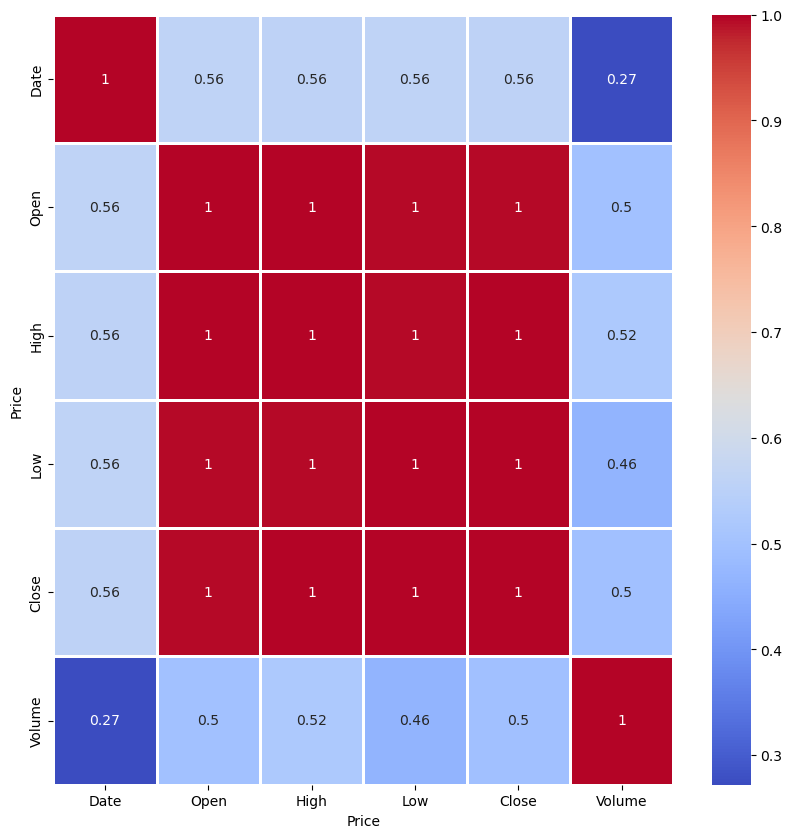

In [19]:
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')
df['Date'] = pd.to_datetime(df['Date'])
df['Date_num'] = df['Date'].map(pd.Timestamp.toordinal)
plt.figure(figsize=(10,10))
sns.heatmap(df[['Date','Open','High','Low','Close','Volume']].corr(),annot=True,cmap='coolwarm',linewidths=2
)
plt.show()

<Axes: xlabel='Price'>

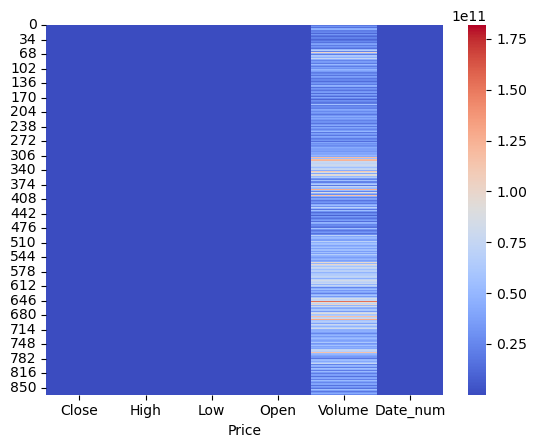

In [20]:
sns.heatmap(df.drop('Date', axis=1),cmap='coolwarm')

In [21]:
df['H-L'] = df['High'] - df['Low']
df['O-C'] = df['Open'] - df['Close']
ma_1 = 7
ma_2 = 17
ma_3 = 30

df[f'SMA_{ma_1}'] = df['Close'].rolling(window=ma_1).mean()
df[f'SMA_{ma_2}'] = df['Close'].rolling(window=ma_2).mean()
df[f'SMA_{ma_3}'] = df['Close'].rolling(window=ma_3).mean()

df[f'SD_{ma_1}'] = df['Close'].rolling(window=ma_1).std()
df[f'SD_{ma_3}'] = df['Close'].rolling(window=ma_3).std()
df.dropna(inplace=True)

df.to_csv(f"data_bitcon.csv",index=False)

In [22]:
features1 = ['Open', 'High', 'Low', 'Close', 'Volume']
features2 = [
    'H-L', 'O-C',
    f'SMA_{ma_1}',
    f'SMA_{ma_2}',
    f'SMA_{ma_3}',
    f'SD_{ma_1}',
    f'SD_{ma_3}'
]
features3 = features1 + features2
target = 'Close'

X1 = df[features1]
X2 = df[features2]
X3 = df[features3]

y = df[[target]]

train_size = int(len(df) * 0.8)

X1_train, X1_test = X1[:train_size], X1[train_size:]
X2_train, X2_test = X2[:train_size], X2[train_size:]
X3_train, X3_test = X3[:train_size], X3[train_size:]

y_train, y_test = y[:train_size], y[train_size:]

In [23]:
scaler_x1 = MinMaxScaler()
scaler_x2 = MinMaxScaler()
scaler_x3 = MinMaxScaler()

X1_train_scaled = scaler_x1.fit_transform(X1_train)
X1_test_scaled = scaler_x1.transform(X1_test)

X2_train_scaled = scaler_x2.fit_transform(X2_train)
X2_test_scaled = scaler_x2.transform(X2_test)

X3_train_scaled = scaler_x3.fit_transform(X3_train)
X3_test_scaled = scaler_x3.transform(X3_test)

scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [24]:
X1_train_scaled = pd.DataFrame(X1_train_scaled, columns=features1, index=X1_train.index)
X1_test_scaled = pd.DataFrame(X1_test_scaled, columns=features1, index=X1_test.index)

X2_train_scaled = pd.DataFrame(X2_train_scaled, columns=features2, index=X2_train.index)
X2_test_scaled = pd.DataFrame(X2_test_scaled, columns=features2, index=X2_test.index)

X3_train_scaled = pd.DataFrame(X3_train_scaled, columns=features3, index=X3_train.index)
X3_test_scaled = pd.DataFrame(X3_test_scaled, columns=features3, index=X3_test.index)

y_train_scaled = pd.DataFrame(y_train_scaled, columns=[target], index=y_train.index)
y_test_scaled = pd.DataFrame(y_test_scaled, columns=[target], index=y_test.index)

<Axes: >

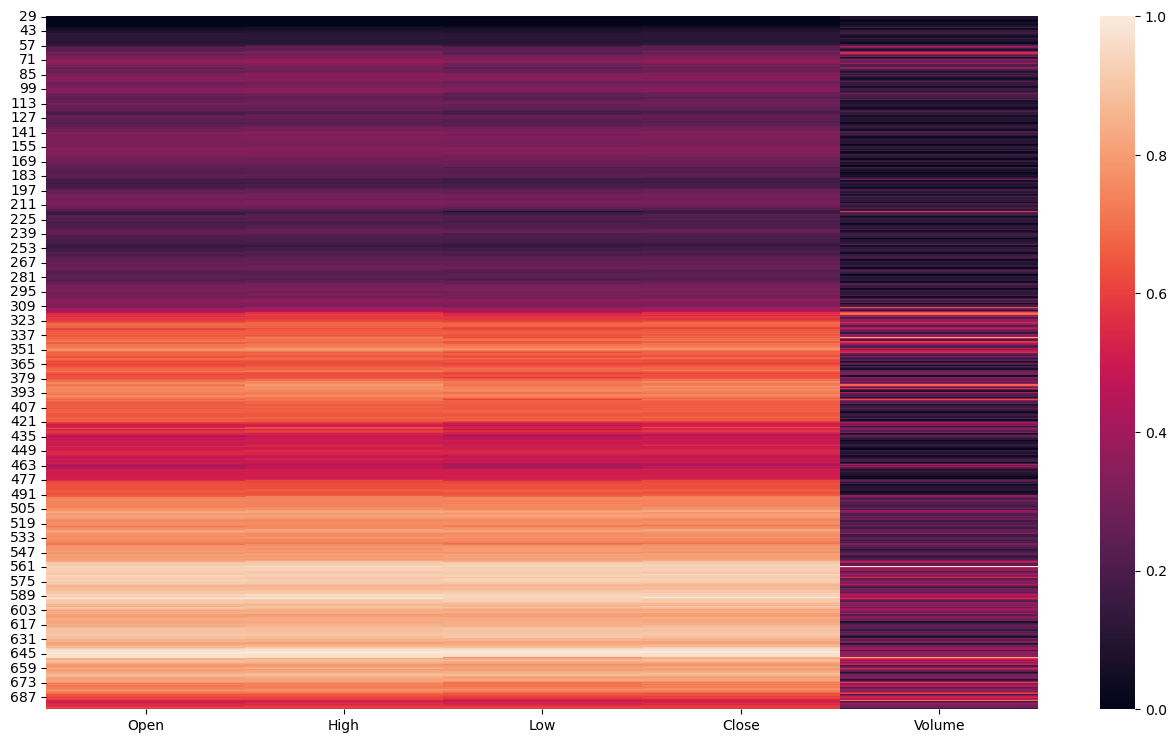

In [25]:
plt.figure(figsize=(16,9))
sns.heatmap(X1_train_scaled)

In [26]:
def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    for i in range(time_steps, len(X)):
        Xs.append(X.iloc[i-time_steps:i].values)
        ys.append(y.iloc[i].values)
    return np.array(Xs), np.array(ys)

In [27]:
time_steps = 30

X1_train_seq, y1_train_seq = create_sequences(X1_train_scaled, y_train_scaled, time_steps)
X1_test_seq, y1_test_seq = create_sequences(X1_test_scaled, y_test_scaled, time_steps)

X2_train_seq, y2_train_seq = create_sequences(X2_train_scaled, y_train_scaled, time_steps)
X2_test_seq, y2_test_seq = create_sequences(X2_test_scaled, y_test_scaled, time_steps)

X3_train_seq, y3_train_seq = create_sequences(X3_train_scaled, y_train_scaled, time_steps)
X3_test_seq, y3_test_seq = create_sequences(X3_test_scaled, y_test_scaled, time_steps)

In [28]:
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(
        units=50,
        return_sequences=True,
        input_shape=input_shape
    ))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

In [29]:
model1 = build_lstm_model((X1_train_seq.shape[1], X1_train_seq.shape[2]))
model2 = build_lstm_model((X2_train_seq.shape[1], X2_train_seq.shape[2]))
model3 = build_lstm_model((X3_train_seq.shape[1], X3_train_seq.shape[2]))

c:\Users\NKAQuoc002\anaconda3\envs\ML\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
history1 = model1.fit(
    X1_train_seq, y1_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

history2 = model2.fit(
    X2_train_seq, y2_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

history3 = model3.fit(
    X3_train_seq, y3_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0435 - val_loss: 0.0187
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0118 - val_loss: 0.0105
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082 - val_loss: 0.0071
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - val_loss: 0.0067
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060 - val_loss: 0.0069
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0056 - val_loss: 0.0065
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0058 - val_loss: 0.0076
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0049 - val_loss: 0.0075
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051 - val_loss: 0.0080
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0050 - val_loss: 0.0067
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

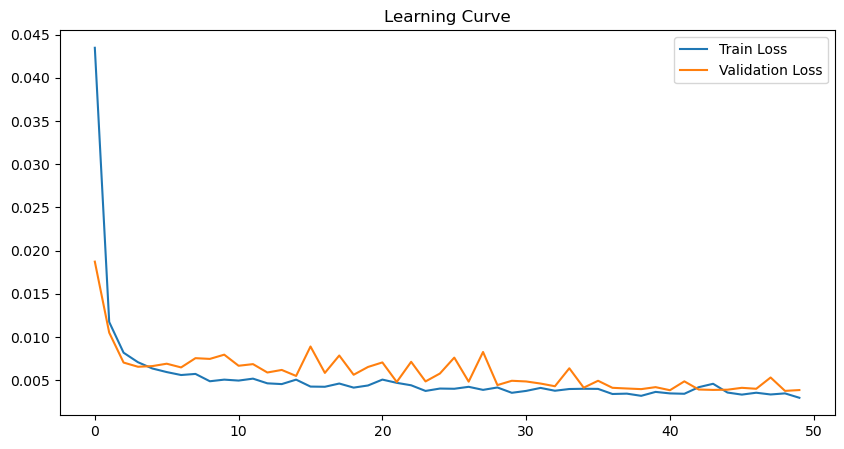

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [31]:
pred1 = model1.predict(X1_test_seq)
pred2 = model2.predict(X2_test_seq)
pred3 = model3.predict(X3_test_seq)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021C7685EF80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


In [32]:
pred1_real = scaler_y.inverse_transform(pred1)
pred2_real = scaler_y.inverse_transform(pred2)
pred3_real = scaler_y.inverse_transform(pred3)

y_test_real = scaler_y.inverse_transform(y1_test_seq)

In [33]:
y_true = y_test_real.flatten()
pred1 = pred1_real.flatten()
pred2 = pred2_real.flatten()
pred3 = pred3_real.flatten()

In [34]:
compare_df = pd.DataFrame({
    "Thực tế": y_true,
    "Dự đoán Model 1": pred1,
    "Lệch Model 1": abs(y_true - pred1),
    "Dự đoán Model 2": pred2,
    "Lệch Model 2": abs(y_true - pred2),
    "Dự đoán Model 3": pred3,
    "Lệch Model 3": abs(y_true - pred3)
})

In [35]:
compare_df.head(20)

,Thực tế,Dự đoán Model 1,Lệch Model 1,Dự đoán Model 2,Lệch Model 2,Dự đoán Model 3,Lệch Model 3
0,88430.132812,87672.312500,757.820312,86806.750000,1623.382812,84816.906250,3613.226562
1,87508.828125,87886.757812,377.929688,87029.375000,479.453125,85078.593750,2430.234375
2,88731.984375,88063.718750,668.265625,86828.234375,1903.750000,84953.179688,3778.804688
3,89944.695313,88100.328125,1844.367188,86997.343750,2947.351563,85284.406250,4660.289063
4,90603.187500,88498.796875,2104.390625,87365.296875,3237.890625,85942.375000,4660.812500
5,91413.492188,88842.179688,2571.312500,87758.554688,3654.937500,86625.179688,4788.312500
6,93882.554688,89317.937500,4564.617188,88245.250000,5637.304688,87447.187500,6435.367188
7,93729.031250,90283.281250,3445.750000,89267.007812,4462.023438,88875.390625,4853.640625
8,91308.054688,91355.765625,47.710938,89909.890625,1398.164062,89790.945312,1517.109375
9,91027.125000,92087.570312,1060.445312,89598.664062,1428.460938,89605.453125,1421.671875


In [44]:
def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )
    mae = mean_absolute_error(
        y_true, y_pred
    )
    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100
    print(name)
    print("RMSE:", round(rmse, 2))
    print("MAE:", round(mae, 2))
    print("Mean Relative Error (%):",
          round(mape, 2), "%")
    print("-" * 40)

In [48]:
evaluate_model(y_test_real, pred1_real, "Model 1 - OHLCV")
evaluate_model(y_test_real, pred2_real, "Model 2 - Feature mới")
evaluate_model(y_test_real, pred3_real, "Model 3 - sum feature 1 + 2")

Model 1 - OHLCV
RMSE: 3495.07
MAE: 2381.58
Mean Relative Error (%): 3.18 %
----------------------------------------
Model 2 - Feature mới
RMSE: 4392.61
MAE: 3427.88
Mean Relative Error (%): 4.57 %
----------------------------------------
Model 3 - sum feature 1 + 2
RMSE: 2931.55
MAE: 2319.26
Mean Relative Error (%): 3.05 %
----------------------------------------


In [ ]:
import plotly.graph_objects as go

y_true = y_test_real.flatten()

pred1 = pred1_real.flatten()
pred2 = pred2_real.flatten()
pred3 = pred3_real.flatten()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_true,
        mode='lines',
        name='Giá thực tế',
        line=dict(color='blue')
    )
)
fig.add_trace(
    go.Scatter(
        y=pred1,
        mode='lines',
        name='Model 1 - OHLCV',
        line=dict(color='red')
    )
)
fig.add_trace(
    go.Scatter(
        y=pred2,
        mode='lines',
        name='Model 2 - Feature mới',
        line=dict(color='green')
    )
)
fig.add_trace(
    go.Scatter(
        y=pred3,
        mode='lines',
        name='Model 3 - Feature 1 + 2',
        line=dict(color='orange')
    )
)
fig.update_layout(
    title='So sánh dự đoán giá Bitcoin giữa 3 mô hình',
    xaxis_title='Thời gian',
    yaxis_title='Giá Close (USD)',
    template='plotly_white',
    width=1200,
    height=700
)

fig.show()

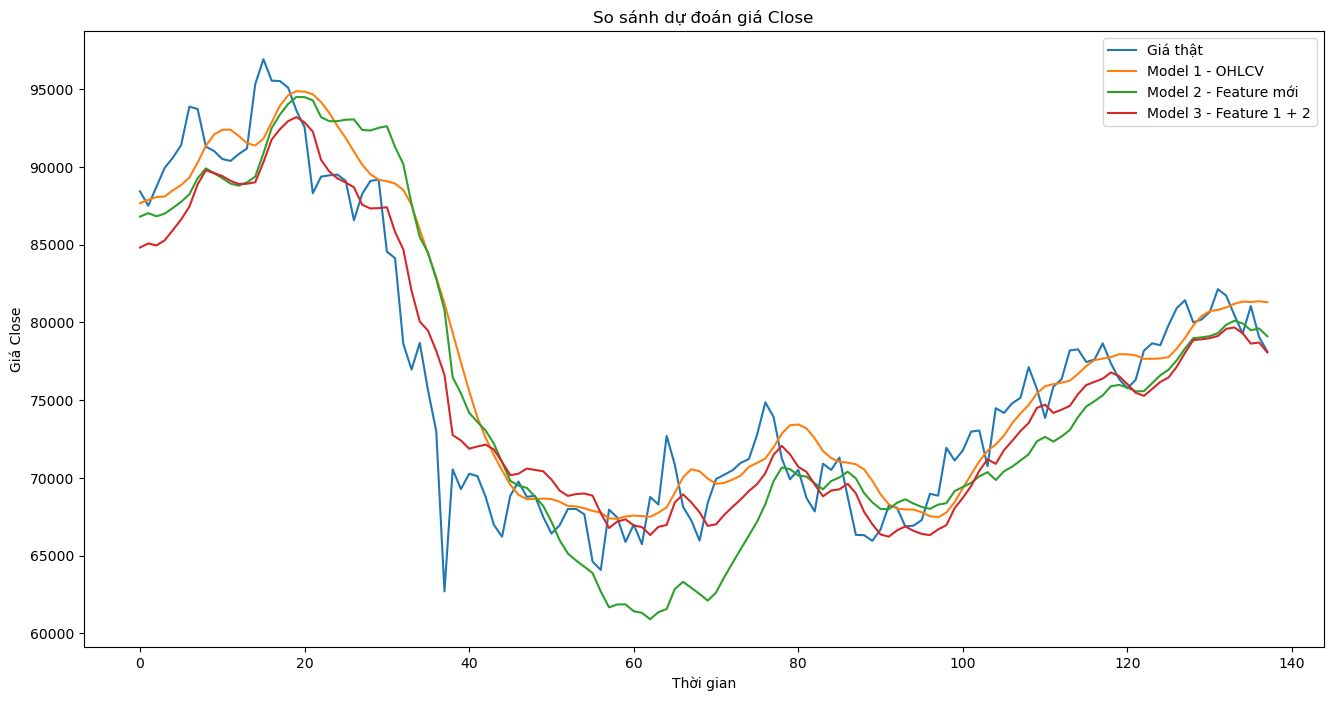

In [52]:
plt.figure(figsize=(16, 8))

plt.plot(y_test_real, label='Giá thật')
plt.plot(pred1_real, label='Model 1 - OHLCV')
plt.plot(pred2_real, label='Model 2 - Feature mới')
plt.plot(pred3_real, label='Model 3 - Feature 1 + 2')

plt.title('So sánh dự đoán giá Close')
plt.xlabel('Thời gian')
plt.ylabel('Giá Close')
plt.legend()
plt.show()